In [1]:
import numpy as np
import cvxpy as cp
import matplotlib.pyplot as plt

In [2]:
# --- 1. Parámetros del Controlador ---
N = 3          
r = 0.1        
u_max = 1.0    
num_muestras = 1000 # Enseñar a la red 1000 situaciones diferentes

X_dataset = []
U_dataset = []

# Generar estados aleatorios uniformes (Exploración del espacio de estados)
np.random.seed(42) # Para que siempre te dé el mismo dataset
estados_aleatorios = np.random.uniform(-6.0, 6.0, num_muestras)

print("Generando el Experto MPC para 1000 estados aleatorios...")

Generando el Experto MPC para 1000 estados aleatorios...


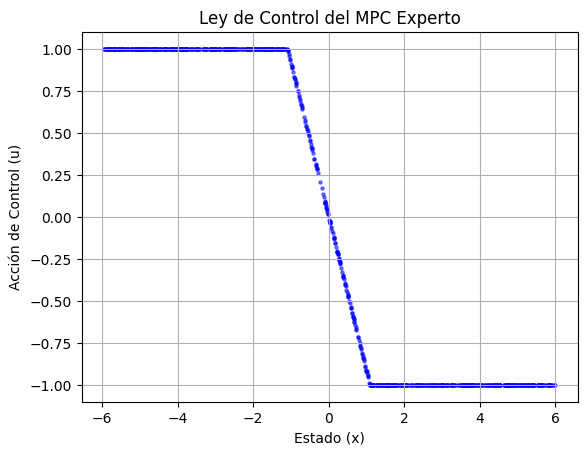

In [3]:
# --- 2. Recopilación de Datos (Lazo Abierto para Dataset) ---
for x_actual in estados_aleatorios:
    
    x = cp.Variable(N + 1)
    u = cp.Variable(N)
    
    costo = 0
    restricciones = [x[0] == x_actual] 
    
    for i in range(N):
        costo += cp.square(x[i]) + r * cp.square(u[i])
        restricciones += [x[i+1] == x[i] + u[i]]
        restricciones += [cp.abs(u[i]) <= u_max]
        
    costo += cp.square(x[N]) 
    
    prob = cp.Problem(cp.Minimize(costo), restricciones)
    prob.solve(solver=cp.OSQP)
    
    # Guardar el par (Estado, Acción Óptima)
    X_dataset.append(x_actual)
    U_dataset.append(u.value[0])

# Convertir a arrays para Keras
X_train = np.array(X_dataset, dtype=np.float32).reshape(-1, 1)
Y_train = np.array(U_dataset, dtype=np.float32).reshape(-1, 1)

# Visualizar la "Ley de Control" que la IA debe aprender
plt.scatter(X_train, Y_train, s=5, alpha=0.5, color='blue')
plt.title("Ley de Control del MPC Experto")
plt.xlabel("Estado (x)")
plt.ylabel("Acción de Control (u)")
plt.grid(True)
plt.show()

In [4]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

In [5]:
# Configuraciones de entrenamiento
epochs_base = 150
epochs_ft = 50 # Fine-tuning para QAT y Pruning
batch_size = 32

In [7]:
# 2. Construir y Entrenar la Red Neuronal Clonadora   
base_model = tf.keras.Sequential([
    tf.keras.layers.Dense(16, activation='relu', input_shape=(1,)),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(1, activation='linear') # Salida lineal para regresión
])

base_model.compile(optimizer='adam', loss='mse')
print("Entrenando Modelo Float32")
base_model.fit(X_train, Y_train, epochs=epochs_base, batch_size=batch_size, verbose=2)

Entrenando Modelo Float32
Epoch 1/150
32/32 - 1s - loss: 4.2369 - 722ms/epoch - 23ms/step
Epoch 2/150
32/32 - 0s - loss: 1.4731 - 37ms/epoch - 1ms/step
Epoch 3/150
32/32 - 0s - loss: 0.4439 - 36ms/epoch - 1ms/step
Epoch 4/150
32/32 - 0s - loss: 0.1870 - 35ms/epoch - 1ms/step
Epoch 5/150
32/32 - 0s - loss: 0.1387 - 34ms/epoch - 1ms/step
Epoch 6/150
32/32 - 0s - loss: 0.1182 - 33ms/epoch - 1ms/step
Epoch 7/150
32/32 - 0s - loss: 0.1014 - 33ms/epoch - 1ms/step
Epoch 8/150
32/32 - 0s - loss: 0.0864 - 33ms/epoch - 1ms/step
Epoch 9/150
32/32 - 0s - loss: 0.0738 - 34ms/epoch - 1ms/step
Epoch 10/150
32/32 - 0s - loss: 0.0621 - 32ms/epoch - 1ms/step
Epoch 11/150
32/32 - 0s - loss: 0.0520 - 34ms/epoch - 1ms/step
Epoch 12/150
32/32 - 0s - loss: 0.0416 - 34ms/epoch - 1ms/step
Epoch 13/150
32/32 - 0s - loss: 0.0287 - 35ms/epoch - 1ms/step
Epoch 14/150
32/32 - 0s - loss: 0.0192 - 71ms/epoch - 2ms/step
Epoch 15/150
32/32 - 0s - loss: 0.0123 - 50ms/epoch - 2ms/step
Epoch 16/150
32/32 - 0s - loss: 0.00

In [8]:
X_train.shape

(1000, 1)

In [9]:
import tensorflow as tf
import tensorflow_model_optimization as tfmot
import numpy as np
import os
import tempfile
import matplotlib.pyplot as plt

In [13]:
print(tf.__version__)
print(tfmot.__version__)

##versiones compatibles

2.13.0
0.8.0


In [10]:
# =========================================================
# 0. PREPARACIÓN (Asumiendo que X_train e Y_train ya existen)
# =========================================================
def representative_dataset():
    for x_val in X_train[:100]:
        yield [np.array([x_val], dtype=np.float32)]

def get_gzipped_model_size(file):
    import zipfile
    _, zipped_file = tempfile.mkstemp('.zip')
    with zipfile.ZipFile(zipped_file, 'w', compression=zipfile.ZIP_DEFLATED) as f:
        f.write(file)
    return os.path.getsize(zipped_file)

In [14]:
# =========================================================
# 2. FULL PTQ (Solo Cuantización INT8)
# =========================================================
print("--- 2. Generando Full PTQ INT8 ---")
converter_ptq = tf.lite.TFLiteConverter.from_keras_model(base_model)
converter_ptq.optimizations = [tf.lite.Optimize.DEFAULT]
converter_ptq.representative_dataset = representative_dataset
ptq_tflite = converter_ptq.convert()

--- 2. Generando Full PTQ INT8 ---
INFO:tensorflow:Assets written to: C:\Users\Alonso\AppData\Local\Temp\tmpqrah68hk\assets


INFO:tensorflow:Assets written to: C:\Users\Alonso\AppData\Local\Temp\tmpqrah68hk\assets
C:\Users\Alonso\.conda\envs\TESIS\lib\site-packages\tensorflow\lite\python\convert.py:887: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


In [15]:
# =========================================================
# 3. FULL QAT (Cuantización Consciente, SIN Poda)
# =========================================================
print("--- 3. Entrenando Full QAT INT8 ---")
# Clonamos la estructura y pesos del modelo base para hacer un QAT justo
base_model_clone = tf.keras.models.clone_model(base_model)
base_model_clone.set_weights(base_model.get_weights())

quantize_model = tfmot.quantization.keras.quantize_model
full_qat_model = quantize_model(base_model_clone)

full_qat_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4), loss='mse')
full_qat_model.fit(X_train, Y_train, epochs=epochs_ft, verbose=0)

converter_fqat = tf.lite.TFLiteConverter.from_keras_model(full_qat_model)
converter_fqat.optimizations = [tf.lite.Optimize.DEFAULT]
converter_fqat.representative_dataset = representative_dataset
full_qat_tflite = converter_fqat.convert()

--- 3. Entrenando Full QAT INT8 ---
INFO:tensorflow:Assets written to: C:\Users\Alonso\AppData\Local\Temp\tmpu9p_zd0q\assets


INFO:tensorflow:Assets written to: C:\Users\Alonso\AppData\Local\Temp\tmpu9p_zd0q\assets
C:\Users\Alonso\.conda\envs\TESIS\lib\site-packages\tensorflow\lite\python\convert.py:887: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


In [16]:
# =========================================================
# 6. SIMULACIÓN FÍSICA Y EVALUACIÓN (Lazo Cerrado)
# =========================================================
print("\n--- SIMULACIÓN DE CONTROL ---")
def inferir_tflite(tflite_model, estado):
    interpreter = tf.lite.Interpreter(model_content=tflite_model)
    interpreter.allocate_tensors()
    in_idx = interpreter.get_input_details()[0]["index"]
    out_idx = interpreter.get_output_details()[0]["index"]
    
    interpreter.set_tensor(in_idx, np.array([[estado]], dtype=np.float32))
    interpreter.invoke()
    return np.clip(interpreter.get_tensor(out_idx)[0][0], -1.0, 1.0)

pasos = 25
estado_inicial = 5.0

historico = {
    'Base (Float32)': [estado_inicial],
    'Full PTQ': [estado_inicial],
    'Full QAT': [estado_inicial],
}

x = {k: estado_inicial for k in historico.keys()}

for _ in range(pasos):
    # Inferencias
    u_base = np.clip(base_model.predict(np.array([[x['Base (Float32)']]]), verbose=0)[0][0], -1.0, 1.0)
    u_fptq = inferir_tflite(ptq_tflite, x['Full PTQ'])
    u_fqat = inferir_tflite(full_qat_tflite, x['Full QAT'])
    
    # Planta Física
    x['Base (Float32)'] += u_base
    x['Full PTQ'] += u_fptq
    x['Full QAT'] += u_fqat
    
    # Guardar histórico
    for k in historico.keys():
        historico[k].append(x[k])


--- SIMULACIÓN DE CONTROL ---


In [18]:
# Guardar modelos para medir tamaño
base_file = "base_model.keras"
base_model.save(base_file)

rutas = {
    'Full PTQ': ptq_tflite,
    'Full QAT': full_qat_tflite,
}

print("\n--- TAMAÑOS DE MEMORIA (Aprox Flash Comprimida) ---")
print(f"Base Float32 : {get_gzipped_model_size(base_file)} bytes")
for nombre, modelo in rutas.items():
    _, archivo = tempfile.mkstemp('.tflite')
    with open(archivo, 'wb') as f: f.write(modelo)
    print(f"{nombre:<12} : {get_gzipped_model_size(archivo)} bytes")


--- TAMAÑOS DE MEMORIA (Aprox Flash Comprimida) ---
Base Float32 : 5734 bytes
Full PTQ     : 1609 bytes
Full QAT     : 1699 bytes


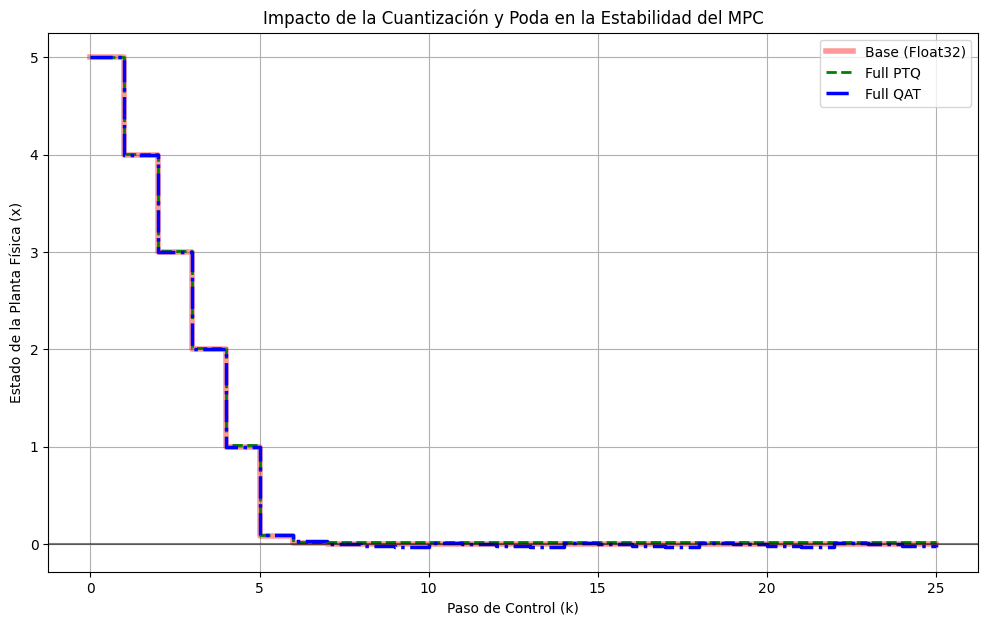

In [19]:
# =========================================================
# 7. GRAFICAR RESULTADOS DE TESIS
# =========================================================
plt.figure(figsize=(12, 7))
estilos = {
    'Base (Float32)': ('red', '-', 4, 0.4), 
    'Full PTQ':       ('green', '--', 2, 1.0), 
    'Full QAT':       ('blue', '-.', 2.5, 1.0),
}

for nombre, (color, estilo, ancho, alfa) in estilos.items():
    plt.step(range(pasos + 1), historico[nombre], label=nombre, color=color, 
             linestyle=estilo, linewidth=ancho, alpha=alfa, where='post')

plt.axhline(0, color='black', alpha=0.5)
plt.title('Impacto de la Cuantización y Poda en la Estabilidad del MPC')
plt.xlabel('Paso de Control (k)')
plt.ylabel('Estado de la Planta Física (x)')
plt.legend()
plt.grid(True)
plt.show()

## Pendulo Invertido

In [20]:
import numpy as np
import scipy.linalg
import tensorflow as tf
import tensorflow_model_optimization as tfmot
import matplotlib.pyplot as plt
import tempfile

In [21]:
# =========================================================
# 1. DINÁMICA DEL PÉNDULO INVERTIDO (Planta Física)
# =========================================================
# Estados: [posición_carro, velocidad_carro, ángulo_péndulo, vel_angular_péndulo]
M, m, l, g = 0.5, 0.2, 0.3, 9.81
Ts = 0.05 # 50 ms de tiempo de muestreo

# Matrices continuas linearizadas
A_c = np.array([
    [0, 1, 0, 0],
    [0, 0, (m*g)/M, 0],
    [0, 0, 0, 1],
    [0, 0, ((M+m)*g)/(M*l), 0]
])
B_c = np.array([[0], [1/M], [0], [1/(M*l)]])

# Discretización simple (Euler)
A = np.eye(4) + A_c * Ts
B = B_c * Ts

In [22]:
# =========================================================
# 2. EL CONTROLADOR EXPERTO (LQR) Y GENERACIÓN DE DATASET
# =========================================================
# Penalizamos fuertemente la caída del ángulo (índice 2)
Q = np.diag([1.0, 1.0, 100.0, 10.0])
R = np.array([[0.1]])

# Resolver la Ecuación de Riccati para obtener la Ganancia Óptima K
P = scipy.linalg.solve_discrete_are(A, B, Q, R)
K = np.linalg.inv(R + B.T @ P @ B) @ (B.T @ P @ A)

# Generar 5000 estados aleatorios (Monte Carlo)
np.random.seed(42)
num_muestras = 5000
# Rangos: pos[-1,1], vel[-1,1], angulo[-0.3, 0.3] rad, vel_ang[-1,1]
X_train = np.random.uniform(
    low=[-1.0, -1.0, -0.3, -1.0], 
    high=[1.0, 1.0, 0.3, 1.0], 
    size=(num_muestras, 4)
).astype(np.float32)

# La acción óptima es U = -K * X
Y_train = (-X_train @ K.T).astype(np.float32)
Y_train = np.clip(Y_train, -10.0, 10.0) # Saturar fuerza del motor a 10 Newtons

def representative_dataset():
    for x_val in X_train[:200]:
        yield [np.array([x_val], dtype=np.float32)]

In [23]:
# =========================================================
# 3. ENTRENAMIENTO DE LOS MODELOS IA
# =========================================================
def build_pendulum_model():
    return tf.keras.Sequential([
        tf.keras.layers.Dense(32, activation='relu', input_shape=(4,)),
        tf.keras.layers.Dense(32, activation='relu'),
        tf.keras.layers.Dense(1, activation='linear')
    ])

print("Entrenando Modelo Base (Float32)...")
base_model = build_pendulum_model()
base_model.compile(optimizer='adam', loss=tf.keras.losses.Huber())
base_model.fit(X_train, Y_train, epochs=150, batch_size=32, verbose=1)

print("Generando PTQ INT8...")
converter_ptq = tf.lite.TFLiteConverter.from_keras_model(base_model)
converter_ptq.optimizations = [tf.lite.Optimize.DEFAULT]
converter_ptq.representative_dataset = representative_dataset
ptq_tflite = converter_ptq.convert()


Entrenando Modelo Base (Float32)...
Epoch 1/150
157/157 [==============================] - 1s 1ms/step - loss: 2.6400
Epoch 2/150
157/157 [==============================] - 0s 1ms/step - loss: 0.4134
Epoch 3/150
157/157 [==============================] - 0s 1ms/step - loss: 0.0395
Epoch 4/150
157/157 [==============================] - 0s 1ms/step - loss: 0.0273
Epoch 5/150
157/157 [==============================] - 0s 1ms/step - loss: 0.0186
Epoch 6/150
157/157 [==============================] - 0s 1ms/step - loss: 0.0134
Epoch 7/150
157/157 [==============================] - 0s 1ms/step - loss: 0.0097
Epoch 8/150
157/157 [==============================] - 0s 1ms/step - loss: 0.0075
Epoch 9/150
157/157 [==============================] - 0s 1ms/step - loss: 0.0055
Epoch 10/150
157/157 [==============================] - 0s 1ms/step - loss: 0.0043
Epoch 11/150
157/157 [==============================] - 0s 1ms/step - loss: 0.0036
Epoch 12/150
157/157 [==============================] - 0s 1

INFO:tensorflow:Assets written to: C:\Users\Alonso\AppData\Local\Temp\tmp6hlciwou\assets
C:\Users\Alonso\.conda\envs\TESIS\lib\site-packages\tensorflow\lite\python\convert.py:887: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


In [24]:
print("Entrenando QAT INT8...")
base_model_clone = tf.keras.models.clone_model(base_model)
base_model_clone.set_weights(base_model.get_weights())

qat_model = tfmot.quantization.keras.quantize_model(base_model_clone)
lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(initial_learning_rate=2e-3, decay_steps=100, decay_rate=0.9)
qat_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=lr_schedule), loss=tf.keras.losses.Huber())
qat_model.fit(X_train, Y_train, epochs=200, batch_size=32, verbose=1)

converter_qat = tf.lite.TFLiteConverter.from_keras_model(qat_model)
converter_qat.optimizations = [tf.lite.Optimize.DEFAULT]
converter_qat.representative_dataset = representative_dataset
qat_tflite = converter_qat.convert()

Entrenando QAT INT8...
Epoch 1/200
157/157 [==============================] - 1s 2ms/step - loss: 0.1895
Epoch 2/200
157/157 [==============================] - 0s 2ms/step - loss: 0.1507
Epoch 3/200
157/157 [==============================] - 0s 2ms/step - loss: 0.1231
Epoch 4/200
157/157 [==============================] - 0s 2ms/step - loss: 0.1029
Epoch 5/200
157/157 [==============================] - 0s 2ms/step - loss: 0.0890
Epoch 6/200
157/157 [==============================] - 0s 2ms/step - loss: 0.0775
Epoch 7/200
157/157 [==============================] - 0s 2ms/step - loss: 0.0682
Epoch 8/200
157/157 [==============================] - 0s 2ms/step - loss: 0.0616
Epoch 9/200
157/157 [==============================] - 0s 2ms/step - loss: 0.0561
Epoch 10/200
157/157 [==============================] - 0s 2ms/step - loss: 0.0518
Epoch 11/200
157/157 [==============================] - 0s 2ms/step - loss: 0.0481
Epoch 12/200
157/157 [==============================] - 0s 2ms/step - los

INFO:tensorflow:Assets written to: C:\Users\Alonso\AppData\Local\Temp\tmpsm_ite3p\assets
C:\Users\Alonso\.conda\envs\TESIS\lib\site-packages\tensorflow\lite\python\convert.py:887: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


In [25]:
# =========================================================
# 4. SIMULACIÓN EN LAZO CERRADO
# =========================================================
def inferir_tflite(tflite_model, estado):
    interpreter = tf.lite.Interpreter(model_content=tflite_model)
    interpreter.allocate_tensors()
    in_idx = interpreter.get_input_details()[0]["index"]
    out_idx = interpreter.get_output_details()[0]["index"]
    interpreter.set_tensor(in_idx, np.array([estado], dtype=np.float32))
    interpreter.invoke()
    return np.clip(interpreter.get_tensor(out_idx)[0][0], -10.0, 10.0)

pasos = 500
# Condición inicial crítica: Carro en el centro, péndulo inclinado 11 grados (0.2 rad)
estado_inicial = np.array([0.0, 0.0, 0.2, 0.0]) 

historico_angulo = {
    'Base (Float32)': [estado_inicial[2]],
    'PTQ INT8': [estado_inicial[2]],
    'QAT INT8': [estado_inicial[2]]
}

# Clones de los estados para las 3 simulaciones paralelas
x_base = estado_inicial.copy()
x_ptq = estado_inicial.copy()
x_qat = estado_inicial.copy()

print("Simulando Lazo Cerrado...")
for _ in range(pasos):
    # Calcular fuerzas de control
    u_base = np.clip(base_model.predict(np.array([x_base]), verbose=0)[0][0], -10.0, 10.0)
    u_ptq = inferir_tflite(ptq_tflite, x_ptq)
    u_qat = inferir_tflite(qat_tflite, x_qat)
    
    # Actualizar la física (x_k+1 = A*x_k + B*u_k)
    x_base = A @ x_base + B.flatten() * u_base
    x_ptq = A @ x_ptq + B.flatten() * u_ptq
    x_qat = A @ x_qat + B.flatten() * u_qat
    
    # Guardar solo el Ángulo del péndulo para la gráfica
    historico_angulo['Base (Float32)'].append(x_base[2])
    historico_angulo['PTQ INT8'].append(x_ptq[2])
    historico_angulo['QAT INT8'].append(x_qat[2])

Simulando Lazo Cerrado...


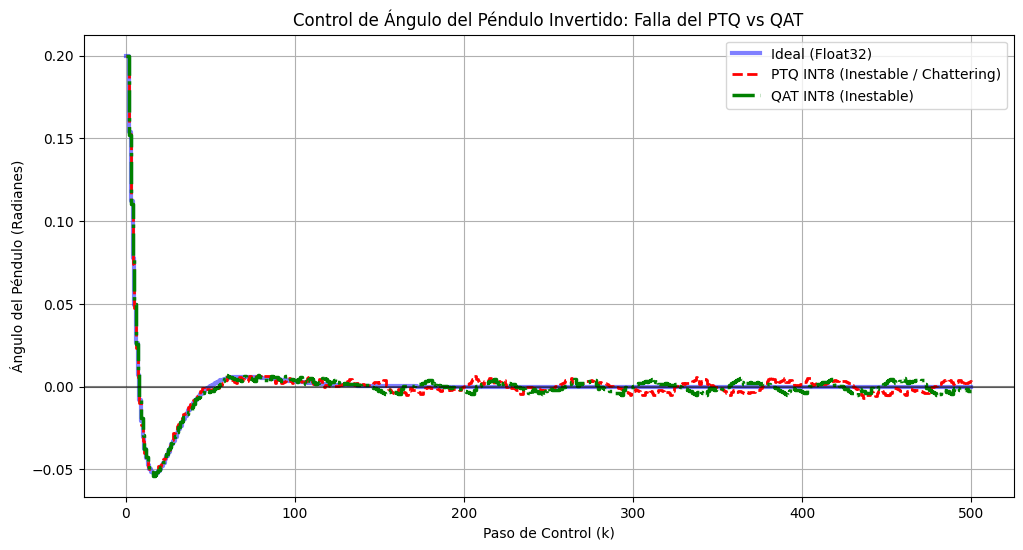

In [26]:
# =========================================================
# 5. GRÁFICA DE RESULTADOS
# =========================================================
plt.figure(figsize=(12, 6))
plt.step(range(pasos + 1), historico_angulo['Base (Float32)'], label='Ideal (Float32)', color='blue', linewidth=3, alpha=0.5, where='post')
plt.step(range(pasos + 1), historico_angulo['PTQ INT8'], label='PTQ INT8 (Inestable / Chattering)', color='red', linestyle='--', linewidth=2, where='post')
plt.step(range(pasos + 1), historico_angulo['QAT INT8'], label='QAT INT8 (Inestable)', color='green', linestyle='-.', linewidth=2.5, where='post')

plt.axhline(0, color='black', alpha=0.5)
plt.title('Control de Ángulo del Péndulo Invertido: Falla del PTQ vs QAT')
plt.xlabel('Paso de Control (k)')
plt.ylabel('Ángulo del Péndulo (Radianes)')
plt.legend()
plt.grid(True)
plt.show()

## 16x8 Quantization

In [27]:
# --- Cuantización a 16x8 Bits (Activaciones INT16, Pesos INT8) ---
converter_16bit = tf.lite.TFLiteConverter.from_keras_model(base_model)
converter_16bit.optimizations = [tf.lite.Optimize.DEFAULT]

# 1. Definir que queremos operaciones de 16 bits para las activaciones
converter_16bit.target_spec.supported_ops = [
    tf.lite.OpsSet.EXPERIMENTAL_TFLITE_BUILTINS_ACTIVATIONS_INT16_WEIGHTS_INT8
]

# 2. Requerido: Función representativa
converter_16bit.representative_dataset = representative_dataset

# 3. Convertir
tflite_16bit_model = converter_16bit.convert()

INFO:tensorflow:Assets written to: C:\Users\Alonso\AppData\Local\Temp\tmpim2hcuce\assets


INFO:tensorflow:Assets written to: C:\Users\Alonso\AppData\Local\Temp\tmpim2hcuce\assets


In [28]:
# =========================================================
# 4. SIMULACIÓN EN LAZO CERRADO
# =========================================================
def inferir_tflite(tflite_model, estado):
    interpreter = tf.lite.Interpreter(model_content=tflite_model)
    interpreter.allocate_tensors()
    in_idx = interpreter.get_input_details()[0]["index"]
    out_idx = interpreter.get_output_details()[0]["index"]
    interpreter.set_tensor(in_idx, np.array([estado], dtype=np.float32))
    interpreter.invoke()
    return np.clip(interpreter.get_tensor(out_idx)[0][0], -10.0, 10.0)

pasos = 500
# Condición inicial crítica: Carro en el centro, péndulo inclinado 11 grados (0.2 rad)
estado_inicial = np.array([0.0, 0.0, 0.2, 0.0]) 

historico_angulo = {
    'Base (Float32)': [estado_inicial[2]],
    'PTQ INT16X8': [estado_inicial[2]]
}

# Clones de los estados para las 3 simulaciones paralelas
x_base = estado_inicial.copy()
x_ptq = estado_inicial.copy()

print("Simulando Lazo Cerrado...")
for _ in range(pasos):
    # Calcular fuerzas de control
    u_base = np.clip(base_model.predict(np.array([x_base]), verbose=0)[0][0], -10.0, 10.0)
    u_ptq = inferir_tflite(tflite_16bit_model, x_ptq)
    
    # Actualizar la física (x_k+1 = A*x_k + B*u_k)
    x_base = A @ x_base + B.flatten() * u_base
    x_ptq = A @ x_ptq + B.flatten() * u_ptq
    
    # Guardar solo el Ángulo del péndulo para la gráfica
    historico_angulo['Base (Float32)'].append(x_base[2])
    historico_angulo['PTQ INT16X8'].append(x_ptq[2])

Simulando Lazo Cerrado...


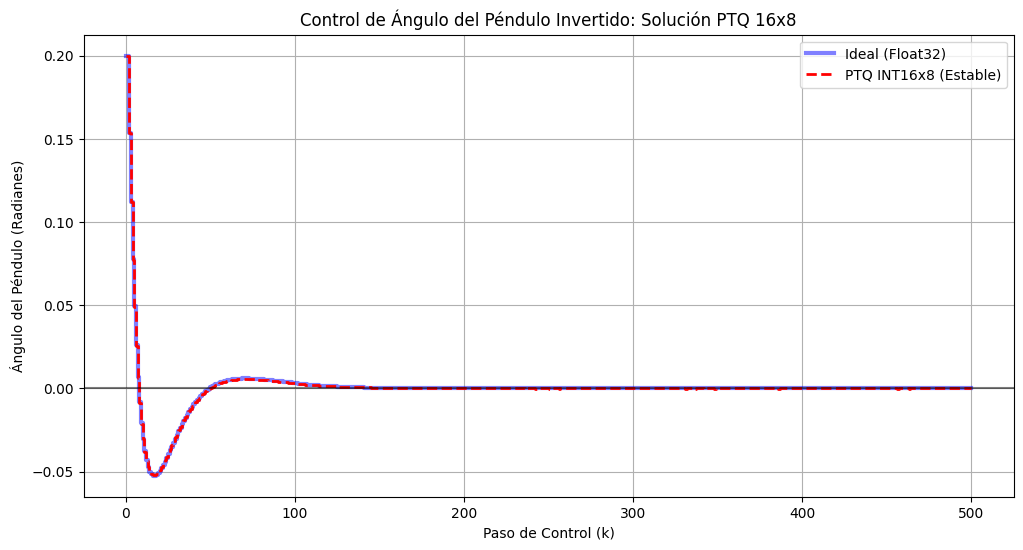

In [29]:
# =========================================================
# 5. GRÁFICA DE RESULTADOS
# =========================================================
plt.figure(figsize=(12, 6))
plt.step(range(pasos + 1), historico_angulo['Base (Float32)'], label='Ideal (Float32)', color='blue', linewidth=3, alpha=0.5, where='post')
plt.step(range(pasos + 1), historico_angulo['PTQ INT16X8'], label='PTQ INT16x8 (Estable)', color='red', linestyle='--', linewidth=2, where='post')

plt.axhline(0, color='black', alpha=0.5)
plt.title('Control de Ángulo del Péndulo Invertido: Solución PTQ 16x8')
plt.xlabel('Paso de Control (k)')
plt.ylabel('Ángulo del Péndulo (Radianes)')
plt.legend()
plt.grid(True)
plt.show()

In [30]:
# Guardar modelos para medir tamaño

rutas = {
    'Full PTQ': ptq_tflite,
    'Full QAT': full_qat_tflite,
    'PTQ INT16X8': tflite_16bit_model
}

print("\n--- TAMAÑOS DE MEMORIA (Aprox Flash Comprimida) ---")
print(f"Base Float32 : {get_gzipped_model_size(base_file)} bytes")
for nombre, modelo in rutas.items():
    _, archivo = tempfile.mkstemp('.tflite')
    with open(archivo, 'wb') as f: f.write(modelo)
    print(f"{nombre:<12} : {get_gzipped_model_size(archivo)} bytes")


--- TAMAÑOS DE MEMORIA (Aprox Flash Comprimida) ---
Base Float32 : 5734 bytes
Full PTQ     : 2632 bytes
Full QAT     : 1699 bytes
PTQ INT16X8  : 2761 bytes


## Comparacion entre Modelos

Calculando métricas de benchmarking... (Esto puede tomar unos segundos)


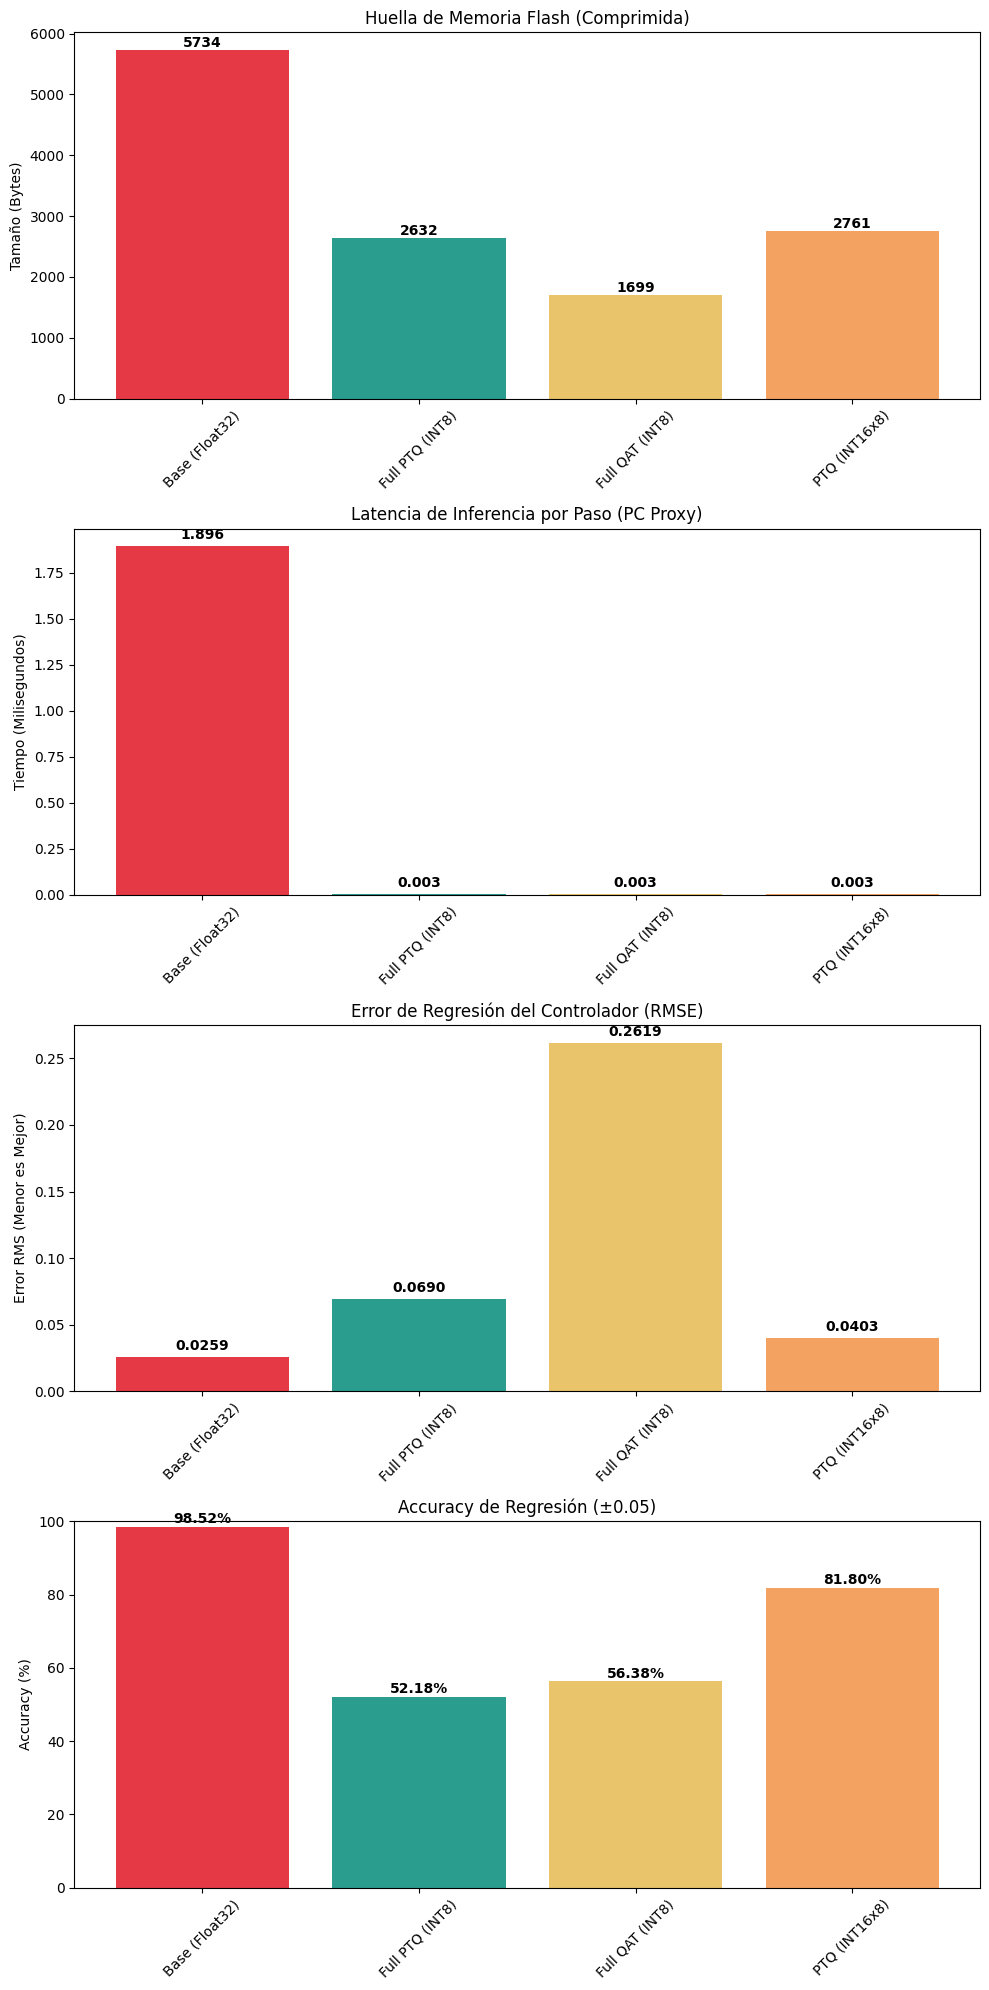

In [39]:
import numpy as np
import time
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

# =========================================================
# 1. FUNCIONES DE MEDICIÓN
# =========================================================

def medir_latencia_tflite(tflite_model, input_data, repeticiones=1000):
    interpreter = tf.lite.Interpreter(model_content=tflite_model)
    interpreter.allocate_tensors()
    in_idx = interpreter.get_input_details()[0]["index"]
    out_idx = interpreter.get_output_details()[0]["index"]
    
    # Calentamiento (Warm-up)
    interpreter.set_tensor(in_idx, np.array([input_data], dtype=np.float32))
    interpreter.invoke()
    
    # Medición real
    inicio = time.time()
    for _ in range(repeticiones):
        interpreter.invoke()
    fin = time.time()
    
    return ((fin - inicio) / repeticiones) * 1000  # ms por inferencia

def medir_latencia_base(modelo, input_data, repeticiones=1000):
    tensor_input = tf.convert_to_tensor(np.array([input_data], dtype=np.float32))
    # Calentamiento
    _ = modelo(tensor_input, training=False)
    
    inicio = time.time()
    for _ in range(repeticiones):
        _ = modelo(tensor_input, training=False)
    fin = time.time()
    return ((fin - inicio) / repeticiones) * 1000  # ms por inferencia

def predecir_dataset_tflite(tflite_model, X_datos):
    interpreter = tf.lite.Interpreter(model_content=tflite_model)
    interpreter.allocate_tensors()
    in_idx = interpreter.get_input_details()[0]["index"]
    out_idx = interpreter.get_output_details()[0]["index"]
    
    predicciones = []
    for x in X_datos:
        interpreter.set_tensor(in_idx, np.array([x], dtype=np.float32))
        interpreter.invoke()
        predicciones.append(interpreter.get_tensor(out_idx)[0][0])
    return np.array(predicciones)

# =========================================================
# 2. EXTRACCIÓN DE MÉTRICAS
# =========================================================
print("Calculando métricas de benchmarking... (Esto puede tomar unos segundos)")

# Nombres de los modelos
nombres = ['Base (Float32)', 'Full PTQ (INT8)', 'Full QAT (INT8)', 'PTQ (INT16x8)']

# 2.1 Memoria (Aprox Flash Zip Bytes)
# (Usamos las rutas guardadas de tu código anterior)




# Guardar modelos para medir tamaño

rutas = {
    'Full PTQ': ptq_tflite,
    'Full QAT': full_qat_tflite,
    'PTQ INT16X8': tflite_16bit_model
}


tamanos_bytes = [
    get_gzipped_model_size(base_file),
    0,
    0,
    0
]

i=1
for nombre, modelo in rutas.items():
    _, archivo = tempfile.mkstemp('.tflite')
    with open(archivo, 'wb') as f: f.write(modelo)
    tamanos_bytes[i]=get_gzipped_model_size(archivo)
    i=i+1



# 2.2 Latencia (ms) usando un estado de prueba
estado_prueba = X_train[0]
latencias_ms = [
    medir_latencia_base(base_model, estado_prueba),
    medir_latencia_tflite(ptq_tflite, estado_prueba),
    medir_latencia_tflite(qat_tflite, estado_prueba),
    medir_latencia_tflite(tflite_16bit_model, estado_prueba)
]

# 2.3 Precisión (RMSE contra el Experto)
# Predecir todo el dataset de entrenamiento/validación
pred_base = base_model.predict(X_train, verbose=0).flatten()
pred_ptq = predecir_dataset_tflite(ptq_tflite, X_train)
pred_qat = predecir_dataset_tflite(qat_tflite, X_train)
pred_16x8 = predecir_dataset_tflite(tflite_16bit_model, X_train)

# Calculamos el Root Mean Squared Error (Raíz del Error Cuadrático Medio)
rmse_list = [
    np.sqrt(mean_squared_error(Y_train, pred_base)),
    np.sqrt(mean_squared_error(Y_train, pred_ptq)),
    np.sqrt(mean_squared_error(Y_train, pred_qat)),
    np.sqrt(mean_squared_error(Y_train, pred_16x8))
]


# =========================================================
# 2.4 ACCURACY DE REGRESIÓN (Tolerancia)
# =========================================================

TOLERANCIA = 0.05

def regression_accuracy(y_true, y_pred, tolerancia=TOLERANCIA):
    y_true = y_true.flatten()
    y_pred = y_pred.flatten()
    
    aciertos = np.abs(y_true - y_pred) < tolerancia
    
    return np.mean(aciertos) * 100.0

accuracy_list = [
    regression_accuracy(Y_train, pred_base),
    regression_accuracy(Y_train, pred_ptq),
    regression_accuracy(Y_train, pred_qat),
    regression_accuracy(Y_train, pred_16x8)
]


# =========================================================
# 3. GRÁFICOS DE COMPARACIÓN (DASHBOARD)
# =========================================================
fig, axs = plt.subplots(4, 1, figsize=(10, 20))
colores = ['#e63946', '#2a9d8f', '#e9c46a', '#f4a261']

# Gráfico 1: Memoria Flash
axs[0].bar(nombres, tamanos_bytes, color=colores)
axs[0].set_title('Huella de Memoria Flash (Comprimida)')
axs[0].set_ylabel('Tamaño (Bytes)')
axs[0].tick_params(axis='x', rotation=45)
for i, v in enumerate(tamanos_bytes):
    axs[0].text(i, v + 50, str(int(v)), ha='center', fontweight='bold')

# Gráfico 2: Latencia de Inferencia
axs[1].bar(nombres, latencias_ms, color=colores)
axs[1].set_title('Latencia de Inferencia por Paso (PC Proxy)')
axs[1].set_ylabel('Tiempo (Milisegundos)')
axs[1].tick_params(axis='x', rotation=45)
for i, v in enumerate(latencias_ms):
    axs[1].text(i, v + (max(latencias_ms)*0.02), f"{v:.3f}", ha='center', fontweight='bold')

# Gráfico 3: Precisión (Error de Control - RMSE)
axs[2].bar(nombres, rmse_list, color=colores)
axs[2].set_title('Error de Regresión del Controlador (RMSE)')
axs[2].set_ylabel('Error RMS (Menor es Mejor)')
axs[2].tick_params(axis='x', rotation=45)
for i, v in enumerate(rmse_list):
    axs[2].text(i, v + (max(rmse_list)*0.02), f"{v:.4f}", ha='center', fontweight='bold')

# Gráfico 4: Accuracy de Regresión
axs[3].bar(nombres, accuracy_list, color=colores)
axs[3].set_title(f'Accuracy de Regresión (±{TOLERANCIA})')
axs[3].set_ylabel('Accuracy (%)')
axs[3].set_ylim([0, 100])
axs[3].tick_params(axis='x', rotation=45)

for i, v in enumerate(accuracy_list):
    axs[3].text(i, v + 1, f"{v:.2f}%", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()